# 딥러닝 라이브러리 2가지
## 텐서플로우(google) - 산업용
* 이미지 관련 라이브러리
* keras를 이용해 코딩이 쉬움
* 순차적, 함수적, 클래스
## 파이토치(meta) - 연구용
* 자연어 관련 라이브러리
* 허깅페이스, 랭체인
* 클래스

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import koreanize_matplotlib

In [2]:
data = pd.read_csv('https://raw.githubusercontent.com/haram4th/ablearn/main/Taitanic_train.csv')
data

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [3]:
data.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [4]:
data = data[['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Embarked']]
data

,Survived,Pclass,Sex,Age,SibSp,Parch,Embarked
0,0,3,male,22.0,1,0,S
1,1,1,female,38.0,1,0,C
2,1,3,female,26.0,0,0,S
3,1,1,female,35.0,1,0,S
4,0,3,male,35.0,0,0,S
...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,S
887,1,1,female,19.0,0,0,S
888,0,3,female,NaN,1,2,S
889,1,1,male,26.0,0,0,C


In [6]:
data['family'] = data['SibSp'] + data['Parch']
data

/tmp/ipykernel_4834/1739076765.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['family'] = data['SibSp'] + data['Parch']


,Survived,Pclass,Sex,Age,SibSp,Parch,Embarked,family
0,0,3,male,22.0,1,0,S,1
1,1,1,female,38.0,1,0,C,1
2,1,3,female,26.0,0,0,S,0
3,1,1,female,35.0,1,0,S,1
4,0,3,male,35.0,0,0,S,0
...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,S,0
887,1,1,female,19.0,0,0,S,0
888,0,3,female,NaN,1,2,S,3
889,1,1,male,26.0,0,0,C,0


In [7]:
data['Age'] = data['Age'].fillna(data['Age'].mean())

/tmp/ipykernel_4834/1548492273.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['Age'] = data['Age'].fillna(data['Age'].mean())


In [9]:
data['Embarked'] = data['Embarked'].fillna(data['Embarked'].mode()[0])

/tmp/ipykernel_4834/1825461941.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['Embarked'] = data['Embarked'].fillna(data['Embarked'].mode()[0])


In [10]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    object 
 3   Age       891 non-null    float64
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Embarked  891 non-null    object 
 7   family    891 non-null    int64  
dtypes: float64(1), int64(5), object(2)
memory usage: 55.8+ KB


In [11]:
data = data.drop(['SibSp', 'Parch'], axis=1)
data

,Survived,Pclass,Sex,Age,Embarked,family
0,0,3,male,22.000000,S,1
1,1,1,female,38.000000,C,1
2,1,3,female,26.000000,S,0
3,1,1,female,35.000000,S,1
4,0,3,male,35.000000,S,0
...,...,...,...,...,...,...
886,0,2,male,27.000000,S,0
887,1,1,female,19.000000,S,0
888,0,3,female,29.699118,S,3
889,1,1,male,26.000000,C,0


In [12]:
data = pd.get_dummies(data, drop_first=True)
data

,Survived,Pclass,Age,family,Sex_male,Embarked_Q,Embarked_S
0,0,3,22.000000,1,True,False,True
1,1,1,38.000000,1,False,False,False
2,1,3,26.000000,0,False,False,True
3,1,1,35.000000,1,False,False,True
4,0,3,35.000000,0,True,False,True
...,...,...,...,...,...,...,...
886,0,2,27.000000,0,True,False,True
887,1,1,19.000000,0,False,False,True
888,0,3,29.699118,3,False,False,True
889,1,1,26.000000,0,True,False,False


In [13]:
X = data.drop('Survived', axis=1)
y = data['Survived']

In [14]:
from sklearn.model_selection import train_test_split

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)

# 딥러닝시에도 데이터의 스케일을 맞춰 주는 것이 좋다
* StandardScaler, MinMaxScaler를 주로 사용, 이상값이 많을 경우 RobustScaler를 사용
* 이진분류(0,1): MinMaxScaler
* 연속값 예측: StandardScaler

In [15]:
from sklearn.preprocessing import MinMaxScaler

In [18]:
mms = MinMaxScaler()
mms_X_train = mms.fit_transform(X_train)
mms_X_test = mms.transform(X_test)
mms_X_train  = pd.DataFrame(mms_X_train, columns=X_train.columns, index=X_train.index)
mms_X_test = pd.DataFrame(mms_X_test, columns=X_test.columns, index=X_test.index)
display(mms_X_train)
display(mms_X_test)

,Pclass,Age,family,Sex_male,Embarked_Q,Embarked_S
748,0.0,0.233476,0.1,1.0,0.0,1.0
45,1.0,0.367921,0.0,1.0,0.0,1.0
28,1.0,0.367921,0.0,0.0,1.0,0.0
633,0.0,0.367921,0.0,1.0,0.0,1.0
403,1.0,0.346569,0.1,1.0,0.0,1.0
...,...,...,...,...,...,...
476,0.5,0.421965,0.1,1.0,0.0,1.0
190,0.5,0.396833,0.0,0.0,0.0,1.0
736,1.0,0.597889,0.4,0.0,0.0,1.0
462,0.0,0.585323,0.0,1.0,0.0,1.0


,Pclass,Age,family,Sex_male,Embarked_Q,Embarked_S
625,0.0,0.761247,0.0,1.0,0.0,1.0
566,1.0,0.233476,0.0,1.0,0.0,1.0
459,1.0,0.367921,0.0,1.0,1.0,0.0
804,1.0,0.334004,0.0,1.0,0.0,1.0
338,1.0,0.560191,0.0,1.0,0.0,1.0
...,...,...,...,...,...,...
184,1.0,0.044986,0.2,0.0,0.0,1.0
607,0.0,0.334004,0.0,1.0,0.0,1.0
624,1.0,0.258608,0.0,1.0,0.0,1.0
103,1.0,0.409399,0.0,1.0,0.0,1.0


# Tensorflow Sequenital API를 사용한 순차적 모델 생성 및 분석
* Sequential: 인공신경망을 순차적으로 작성할 때 사용
* Dense: 층, 레이어
* 1. 신경망 모델 정의
* 2. 신경말 모델 훈련
* 3. 훈련된 모델로 테스트
* 4. 검증

In [22]:
import tensorflow as tf
from tensorflow.keras import Input
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

* 입력층은 반드시 독립변수의 수(input_dim)를 정확히 지정
* 신경망 모델의 은닉층은 2~3개 정도로 한다.
* Dense의 노드수는 2의 배수의 지정 2 4 6 8 16 256
* Dense의 노드는 큰 수에서 작은 수로 줄여나간다.
* 은닉층의 활성화 함수: Reru
* 출력층은 이진분류의 경우 sigmoid, 다중분류일 경우 softmax
* 회귀분석일 경우(종속변수가 연속형(수치형)인 경우) 출력층에 활성화 함수없이 노드를 1로 지정

In [20]:
mms_X_train.shape[1]

6

In [25]:
# 신경망 모델 정의 kearas 3.0, tensorflow 2.19 기준
model = Sequential()
model.add(Input(shape=(mms_X_train.shape[1],))) #입력층
model.add(Dense(64, activation='relu')) # 은닉층
model.add(Dense(32, activation='relu')) # 은닉층
model.add(Dense(16, activation='relu')) # 은닉층
model.add(Dense(1, activation='sigmoid')) # 출력층, 이진분류이므로 sigmoid

# 모델의 파라미터 세팅 model.compile()
* loss: 오차 계산 지표
    * 이진분류: binary_crossentropy
    * 다중분류: categorical_crossentropy
    * 데이터에 0이 많은 희소행렬인 경우: sparse_categorical_crossentropy
    * 연속형데이터(회귀분석): mse
* optimizer: learning_rate
    * adam을 가장 많이 사용
* metrics: 평가지표 accuracy

In [26]:
# 모델의 파라미터 세팅
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 64)             │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,073 (12.00 KB)

 Trainable params: 3,073 (12.00 KB)

 Non-trainable params: 0 (0.00 B)

# 모델 훈련 model.fit(X_train, y_train)
* epochs: 전체 데이터를 한 번 훈련하는 주기
* batch_size: 전체 데이터를 쪼개서 훈련, 데이터의 묶음, 메모리에 맞춰서 크기 조절 (2의 배수) 32, 64로 쪼개서 넣는 것 추천
* validation_data: 검증 데이터로 모델 검증 실시

In [29]:
history = model.fit(mms_X_train, y_train, epochs=100, batch_size=32, validation_data=(mms_X_test, y_test))

Epoch 1/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - accuracy: 0.6163 - loss: 0.6037 - val_accuracy: 0.6269 - val_loss: 0.5768
Epoch 2/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6890 - loss: 0.5522 - val_accuracy: 0.7985 - val_loss: 0.5442
Epoch 3/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8081 - loss: 0.5222 - val_accuracy: 0.7761 - val_loss: 0.5187
Epoch 4/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7910 - loss: 0.5110 - val_accuracy: 0.7761 - val_loss: 0.4999
Epoch 5/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7775 - loss: 0.5016 - val_accuracy: 0.7761 - val_loss: 0.4840
Epoch 6/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7808 - loss: 0.4888 - val_accuracy: 0.7761 - val_loss: 0.4754
Epoch 7/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8156 - loss: 0.4262 - val_accuracy: 0.8172 - val_loss: 0.4633
Epoch 8/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7889 - loss: 0.4655 - val_accuracy: 0.7873 - 

20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8187 - loss: 0.4146 - val_accuracy: 0.8022 - val_loss: 0.4217
Epoch 52/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8430 - loss: 0.4117 - val_accuracy: 0.8172 - val_loss: 0.4190
Epoch 53/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8377 - loss: 0.4008 - val_accuracy: 0.8022 - val_loss: 0.4196
Epoch 54/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8274 - loss: 0.3866 - val_accuracy: 0.7985 - val_loss: 0.4214
Epoch 55/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8113 - loss: 0.4365 - val_accuracy: 0.8060 - val_loss: 0.4213
Epoch 56/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8529 - loss: 0.3680 - val_accuracy: 0.8022 - val_loss: 0.4199
Epoch 57/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8343 - loss: 0.4036 - val_accuracy: 0.8060 - val_loss: 0.4194
Epoch 58/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8419 - loss: 0.3822 - val_accuracy: 0.8097 - val_lo

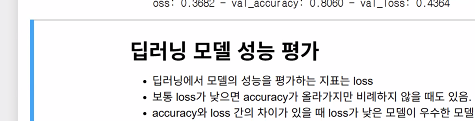

# 딥러닝 모델 성능 평가

* 딥러닝에서 모델의 성능을 평가하는 지표는 loss
* 보통 loss가 낮으면 accuracy가 올라가지만 비례하지 않을 때도 있음
* accuracy와 loss 간의 차이가 있을 때 loss가 낮은 모델이 우수한 모델


In [31]:
score = model.evaluate(mms_X_test, y_test)
print('test loss', score[0])
print('test accuracy', score[1])

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8163 - loss: 0.4386 
test loss 0.4422430396080017
test accuracy 0.8022388219833374


In [32]:
for i in history.history:
    print(i)

accuracy
loss
val_accuracy
val_loss


# 훈련 결과 시각화하기 history.histroy['loss'], history.history['val_loss']

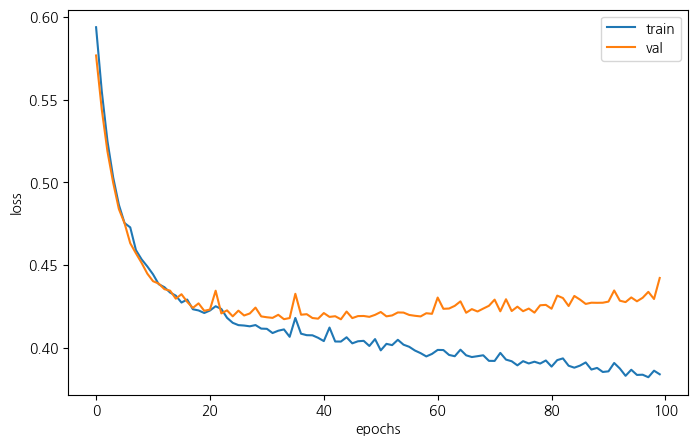

In [36]:
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('epochs')
plt.ylabel('loss')
plt.legend(['train', 'val'])
plt.show()

In [37]:
history = model.fit(mms_X_train, y_train, epochs=100, batch_size=64, validation_data=(mms_X_test, y_test))

Epoch 1/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 221ms/step - accuracy: 0.8445 - loss: 0.3734 - val_accuracy: 0.8172 - val_loss: 0.4293
Epoch 2/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8514 - loss: 0.3593 - val_accuracy: 0.8097 - val_loss: 0.4293
Epoch 3/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8463 - loss: 0.3711 - val_accuracy: 0.8097 - val_loss: 0.4318
Epoch 4/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8409 - loss: 0.4072 - val_accuracy: 0.8097 - val_loss: 0.4308
Epoch 5/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8673 - loss: 0.3401 - val_accuracy: 0.8172 - val_loss: 0.4310
Epoch 6/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8475 - loss: 0.3894 - val_accuracy: 0.8060 - val_loss: 0.4359
Epoch 7/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8528 - loss: 0.3618 - val_accuracy: 0.8172 - val_loss: 0.4309
Epoch 8/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8555 - loss: 0.3714 - val_accuracy: 0

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8465 - loss: 0.3766 - val_accuracy: 0.8022 - val_loss: 0.4453
Epoch 52/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8223 - loss: 0.4119 - val_accuracy: 0.8172 - val_loss: 0.4407
Epoch 53/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8389 - loss: 0.3821 - val_accuracy: 0.7948 - val_loss: 0.4446
Epoch 54/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8412 - loss: 0.3680 - val_accuracy: 0.7948 - val_loss: 0.4457
Epoch 55/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8414 - loss: 0.3750 - val_accuracy: 0.8022 - val_loss: 0.4446
Epoch 56/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8428 - loss: 0.3700 - val_accuracy: 0.8022 - val_loss: 0.4449
Epoch 57/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8501 - loss: 0.3593 - val_accuracy: 0.8060 - val_loss: 0.4453
Epoch 58/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8408 - loss: 0.3865 - val_accuracy: 0.8134 

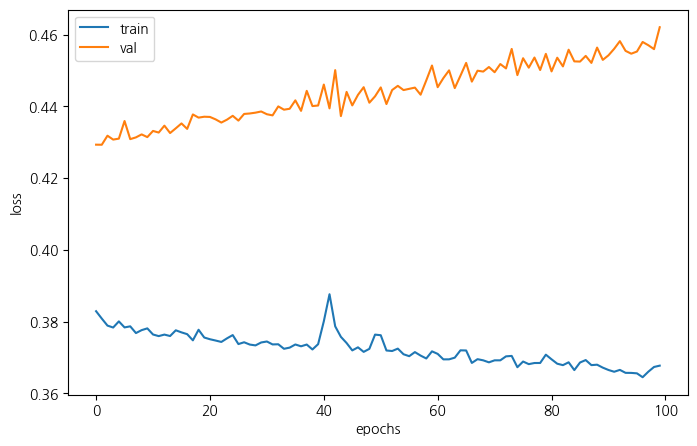

In [38]:
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('epochs')
plt.ylabel('loss')
plt.legend(['train', 'val'])
plt.show()

# 모델의 예측 값 출력

In [39]:
pred = model.predict(mms_X_test)
pred

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step


array([[0.27205846],
       [0.1496747 ],
       [0.14955959],
       [0.13659643],
       [0.08692852],
       [0.4004225 ],
       [0.09630381],
       [0.8506942 ],
       [0.13182712],
       [0.9743293 ],
       [0.8210173 ],
       [0.99794024],
       [0.28250742],
       [0.27144033],
       [0.9084125 ],
       [0.8412455 ],
       [0.14955959],
       [0.33453095],
       [0.9269384 ],
       [0.2895487 ],
       [0.02194277],
       [0.08382485],
       [0.48688263],
       [0.13659643],
       [0.38539597],
       [0.14411655],
       [0.98658967],
       [0.2085558 ],
       [0.13363075],
       [0.3040932 ],
       [0.8982062 ],
       [0.9700224 ],
       [0.14955959],
       [0.8412525 ],
       [0.9934317 ],
       [0.5284426 ],
       [0.14955959],
       [0.03815011],
       [0.14955959],
       [0.31898642],
       [0.09630381],
       [0.97402567],
       [0.62324476],
       [0.99041   ],
       [0.97425234],
       [0.14210951],
       [0.47890538],
       [0.323

In [40]:
pd.DataFrame(pred[:,0])

,0
0,0.272058
1,0.149675
2,0.149560
3,0.136596
4,0.086929
...,...
263,0.850934
264,0.287103
265,0.145064
266,0.126346


In [41]:
result = pd.DataFrame(dict(y_test=y_test, pred=pred[:, 0]))
result

,y_test,pred
625,0,0.272058
566,0,0.149675
459,0,0.149560
804,1,0.136596
338,1,0.086929
...,...,...
184,1,0.850934
607,1,0.287103
624,0,0.145064
103,0,0.126346


In [42]:
result['pred'] = result['pred'].apply(lambda x: 1 if x >= 0.5 else 0)
result

,y_test,pred
625,0,0
566,0,0
459,0,0
804,1,0
338,1,0
...,...,...
184,1,1
607,1,0
624,0,0
103,0,0


In [45]:
from sklearn.metrics import classification_report
print(classification_report(result['y_test'], result['pred']))

              precision    recall  f1-score   support

           0       0.81      0.86      0.83       165
           1       0.75      0.67      0.71       103

    accuracy                           0.79       268
   macro avg       0.78      0.77      0.77       268
weighted avg       0.78      0.79      0.78       268



In [43]:
from sklearn.tree import DecisionTreeClassifier

In [50]:
dtc = DecisionTreeClassifier(random_state=42, max_depth=3)
dtc.fit(mms_X_train, y_train)
pred2 = dtc.predict(mms_X_test)
print(i)
print(classification_report(y_test, pred2))

10
              precision    recall  f1-score   support

           0       0.82      0.88      0.85       165
           1       0.78      0.69      0.73       103

    accuracy                           0.81       268
   macro avg       0.80      0.78      0.79       268
weighted avg       0.80      0.81      0.80       268



In [49]:
for i in range(1, 11):
    dtc = DecisionTreeClassifier(random_state=42)
    dtc.fit(mms_X_train, y_train)
    pred2 = dtc.predict(mms_X_test)
    print(i)
    print(classification_report(y_test, pred2))

1
              precision    recall  f1-score   support

           0       0.79      0.82      0.80       165
           1       0.69      0.64      0.67       103

    accuracy                           0.75       268
   macro avg       0.74      0.73      0.74       268
weighted avg       0.75      0.75      0.75       268

2
              precision    recall  f1-score   support

           0       0.79      0.82      0.80       165
           1       0.69      0.64      0.67       103

    accuracy                           0.75       268
   macro avg       0.74      0.73      0.74       268
weighted avg       0.75      0.75      0.75       268

3
              precision    recall  f1-score   support

           0       0.79      0.82      0.80       165
           1       0.69      0.64      0.67       103

    accuracy                           0.75       268
   macro avg       0.74      0.73      0.74       268
weighted avg       0.75      0.75      0.75       268

4
           

# Functional API를 이용한 함수형 모델
* Sequential API는 단순히 층을 여러 개 쌓는 형태라 복잡한 모델 생성에 한계가 있음.
* Functional API는 입력층과 출력층을 사용자가 직접 정의 가능
* 다중입력(Multi-input), 다중출력(Multi-output)등 복잡한 모델을 정의할 수 있음.
* Input(shape=(독립변수 수))으로 입력층 정의
* 이전 층을 다음 층의 입력으로 사용
* model()에 입력과 출력을 정의

In [51]:
# tensorflow 2.19버전용
from keras.layers import Input, Dense
from keras.models import Model

In [56]:
# 입력층
inputs = Input(shape=(mms_X_train.shape[1],))

# 은닉층
x = Dense(64, activation='relu')(inputs)
x = Dense(32, activation='relu')(x)
x = Dense(16, activation='relu')(x)

# 출력층
outputs = Dense(1, activation='sigmoid')(x)

# 모델 정의
model = Model(inputs=inputs, outputs=outputs)
model.summary()

Model: "functional_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 6)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 64)             │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,073 (12.00 KB)

 Trainable params: 3,073 (12.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 61ms/step - accuracy: 0.4713 - loss: 0.7138 - val_accuracy: 0.6754 - val_loss: 0.6388
Epoch 2/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6904 - loss: 0.6203 - val_accuracy: 0.7575 - val_loss: 0.5908
Epoch 3/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7602 - loss: 0.5756 - val_accuracy: 0.7388 - val_loss: 0.5420
Epoch 4/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7720 - loss: 0.5272 - val_accuracy: 0.7649 - val_loss: 0.5049
Epoch 5/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7571 - loss: 0.5154 - val_accuracy: 0.7724 - val_loss: 0.4872
Epoch 6/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7899 - loss: 0.4617 - val_accuracy: 0.7761 - val_loss: 0.4732
Epoch 7/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7970 - loss: 0.4750 - val_accuracy: 0.7799 - val_loss: 0.4644
Epoch 8/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7983 - loss: 0.4400 - val_accuracy: 0.7761 -

20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8403 - loss: 0.4111 - val_accuracy: 0.8097 - val_loss: 0.4238
Epoch 52/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8484 - loss: 0.4097 - val_accuracy: 0.8097 - val_loss: 0.4233
Epoch 53/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8237 - loss: 0.4008 - val_accuracy: 0.8209 - val_loss: 0.4227
Epoch 54/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8510 - loss: 0.3720 - val_accuracy: 0.8134 - val_loss: 0.4242
Epoch 55/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8234 - loss: 0.4135 - val_accuracy: 0.8284 - val_loss: 0.4230
Epoch 56/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8250 - loss: 0.3968 - val_accuracy: 0.7873 - val_loss: 0.4344
Epoch 57/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8415 - loss: 0.3760 - val_accuracy: 0.8209 - val_loss: 0.4260
Epoch 58/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8401 - loss: 0.3799 - val_accuracy: 0.7948 - val_lo

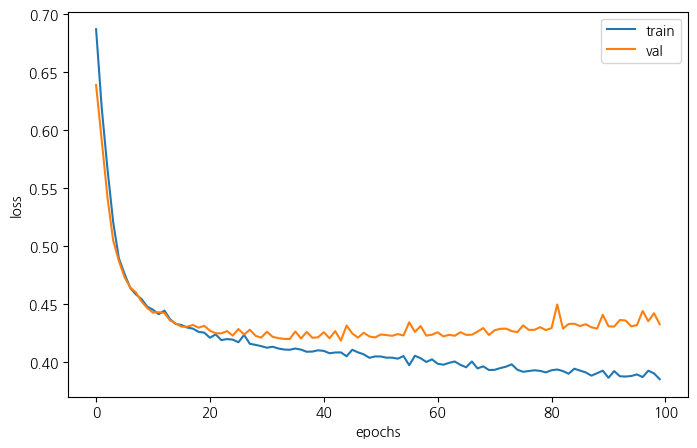

In [58]:
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
history = model.fit(mms_X_train, y_train, epochs=100,
                   batch_size=32,
                   validation_data=(mms_X_test, y_test))
pred = model.predict(mms_X_test)
pred = pd.DataFrame(pred)
pred = pred[0].apply(lambda x: 1 if x > 0.5 else 0)
print(classification_report(y_test, pred))
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('epochs')
plt.ylabel('loss')
plt.legend(['train', 'val'])
plt.show()

# class형으로 만들기 (Model Subclass API)
* class 형태의 모델 정의 방법
* keras의 Model을 상속받아 작성

In [59]:
class Titanic(Model):
    def __init__(self):
        super(Titanic, self).__init__()
        self.dense1 = Dense(128, activation='relu')
        self.dense2 = Dense(64, activation='relu')
        self.dense3 = Dense(32, activation='relu')
        self.dense4 = Dense(16, activation='relu')
        self.classifier = Dense(1, activation='sigmoid')
        
    def call(self, inputs):
        x = self.dense1(inputs)
        x = self.dense2(x)
        x = self.dense3(x)
        x = self.dense4(x)
        return self.classifier(x)

In [60]:
model = Titanic()
model.summary()

Model: "titanic"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_26 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 82ms/step - accuracy: 0.6189 - loss: 0.6613 - val_accuracy: 0.6157 - val_loss: 0.5973
Epoch 2/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6437 - loss: 0.5691 - val_accuracy: 0.7761 - val_loss: 0.5447
Epoch 3/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7846 - loss: 0.5303 - val_accuracy: 0.7687 - val_loss: 0.5122
Epoch 4/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7673 - loss: 0.5221 - val_accuracy: 0.7799 - val_loss: 0.4884
Epoch 5/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7814 - loss: 0.4902 - val_accuracy: 0.7910 - val_loss: 0.4704
Epoch 6/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7874 - loss: 0.4501 - val_accuracy: 0.8134 - val_loss: 0.4528
Epoch 7/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8190 - loss: 0.4262 - val_accuracy: 0.7948 - val_loss: 0.4448
Epoch 8/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8335 - loss: 0.4131 - val_accuracy: 0.8209 - 

20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8519 - loss: 0.3823 - val_accuracy: 0.8246 - val_loss: 0.4293
Epoch 52/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8380 - loss: 0.3985 - val_accuracy: 0.7761 - val_loss: 0.4420
Epoch 53/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8580 - loss: 0.3717 - val_accuracy: 0.7985 - val_loss: 0.4381
Epoch 54/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8356 - loss: 0.3866 - val_accuracy: 0.8246 - val_loss: 0.4308
Epoch 55/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8181 - loss: 0.4182 - val_accuracy: 0.8246 - val_loss: 0.4354
Epoch 56/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8359 - loss: 0.3920 - val_accuracy: 0.7873 - val_loss: 0.4456
Epoch 57/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8441 - loss: 0.3727 - val_accuracy: 0.8022 - val_loss: 0.4454
Epoch 58/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8593 - loss: 0.3469 - val_accuracy: 0.8060 - val_lo

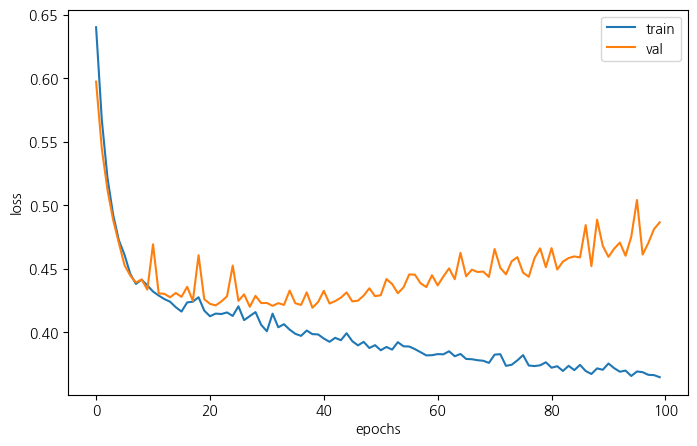

In [61]:
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
history = model.fit(mms_X_train, y_train, epochs = 100, batch_size = 32, validation_data=(mms_X_test, y_test))
pred = model.predict(mms_X_test)
pred = pd.DataFrame(pred)
pred = pred[0].apply(lambda x: 1 if x > 0.5 else 0)
print(classification_report(y_test, pred))
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('epochs')
plt.ylabel('loss')
plt.legend(['train', 'val'])
plt.show()